# Qiskit Circuit Fundamentals
### From Single Qubits to Quantum Volume

**Author:** Abdul Fatah — PhD Researcher, Quantum Computing, ATU Galway, Ireland  
**GitHub:** [fatahjamro](https://github.com/fatahjamro) | **LinkedIn:** [fatahjamro](https://linkedin.com/in/fatahjamro)

> **Qiskit version:** 1.x compatible — all deprecated APIs removed and updated

---

## What This Notebook Covers

This notebook is a structured tour of Qiskit's core building blocks, progressing from a single-qubit circuit to measuring quantum processor performance with Quantum Volume.

| Section | Topic |
|---|---|
| 1 | Setup and imports |
| 2 | Your first quantum circuit — superposition |
| 3 | Measurement and simulation with AerSimulator |
| 4 | Multi-qubit circuits and entanglement |
| 5 | Quantum registers and the Toffoli gate |
| 6 | State visualisation — density matrices and partial trace |
| 7 | Custom gates, controlled gates, and parametrised circuits |
| 8 | Transpilation — from abstract to hardware-native |
| 9 | Batching multiple circuits in a single job |
| 10 | Quantum Volume |

## Prerequisites

- Python 3.9+
- Basic quantum computing concepts (qubits, gates)
- Familiarity with [eigenvalues and eigenvectors](https://github.com/fatahjamro/linear-algebra-for-quantum-computing) helpful but not required

---
## Section 1: Setup and Imports

Install dependencies if needed:
```bash
pip install qiskit qiskit-aer numpy matplotlib
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Core Qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import QuantumVolume
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.visualization import plot_histogram, plot_state_city

# Aer simulator (separate package in Qiskit 1.x)
from qiskit_aer import AerSimulator

print("Imports successful.")

import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Imports successful.
Qiskit version: 2.4.1


---
## Section 2: Your First Quantum Circuit — Superposition

Every qubit starts in state $|0\rangle$. The **Hadamard gate** (H) places it into an equal superposition of $|0\rangle$ and $|1\rangle$:

$$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

Before measurement, the qubit is genuinely in both states simultaneously. Measurement collapses it to $|0\rangle$ or $|1\rangle$ with equal probability — 50% each.

### 2.1 — Single-Qubit Circuit

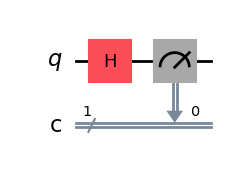

In [3]:
# QuantumCircuit(n_qubits, n_classical_bits)
qc = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit 0 — creates superposition
qc.h(0)

# Measure qubit 0 into classical bit 0
qc.measure(0, 0)

# Draw the circuit (mpl = Matplotlib rendering)
qc.draw('mpl')

### 2.2 — Two-Qubit Circuit with H and X gates

The **X gate** is the quantum NOT gate — it flips $|0\rangle \rightarrow |1\rangle$ and vice versa.

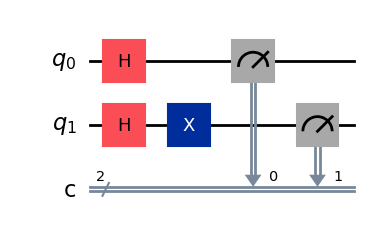

In [4]:
qc2 = QuantumCircuit(2, 2)

qc2.h(0)          # Hadamard on qubit 0
qc2.h(1)          # Hadamard on qubit 1
qc2.x(1)          # X (NOT) gate on qubit 1

# Measure qubit 0 → classical bit 0, qubit 1 → classical bit 1
qc2.measure([0, 1], [0, 1])

qc2.draw('mpl')

---
## Section 3: Measurement and Simulation with AerSimulator

We cannot run on real quantum hardware from a laptop, so we use **AerSimulator** — a high-performance classical simulator that mimics quantum processor behaviour, including noise models.

**Qiskit 1.x workflow:** `transpile` first, then `backend.run()`. The old `execute()` function has been removed.

Measurement counts: {'0': 510, '1': 514}


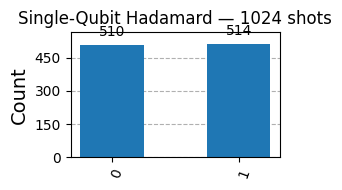

In [5]:
# Initialise simulator
simulator = AerSimulator()

# Build a circuit: H gate then measure (should give ~50/50 result)
qc_sim = QuantumCircuit(1, 1)
qc_sim.h(0)
qc_sim.measure(0, 0)

# Step 1: Transpile — convert circuit to simulator-native gate set
qc_transpiled = transpile(qc_sim, simulator)

# Step 2: Run — execute the transpiled circuit
job = simulator.run(qc_transpiled, shots=1024)
result = job.result()

# Step 3: Extract counts and visualise
counts = result.get_counts()
print("Measurement counts:", counts)

plot_histogram(counts, title='Single-Qubit Hadamard — 1024 shots', figsize=(3, 2))

**Expected result:** approximately 512 counts for `'0'` and 512 for `'1'`. The slight variation is quantum randomness — even in simulation.

### 3.1 — Sequential Measurements on the Same Qubit

Measuring a qubit collapses its state. A second measurement after re-applying H shows that collapse is irreversible — the qubit is re-prepared from whatever state it collapsed into.

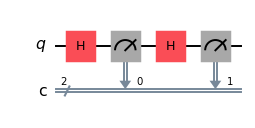

In [6]:
# 1 qubit, 2 classical bits to store two sequential measurements
qc_seq = QuantumCircuit(1, 2)

qc_seq.h(0)
qc_seq.measure(0, 0)   # First measurement → collapses superposition
qc_seq.h(0)
qc_seq.measure(0, 1)   # Second measurement → collapses again

qc_seq.draw('mpl', scale=0.7)

Sequential measurement counts: {'01': 248, '10': 258, '11': 255, '00': 263}


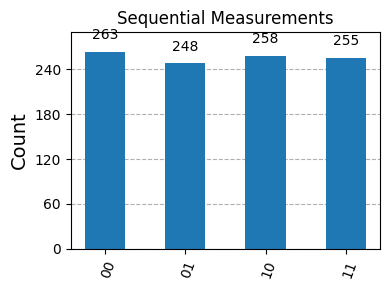

In [7]:
qc_seq_t = transpile(qc_seq, simulator)
counts_seq = simulator.run(qc_seq_t, shots=1024).result().get_counts()
print("Sequential measurement counts:", counts_seq)
plot_histogram(counts_seq, title='Sequential Measurements', figsize=(4, 3))

---
## Section 4: Multi-Qubit Circuits and Entanglement

### 4.1 — The Bell State

The **Bell state** is the simplest example of quantum entanglement. Two qubits become correlated so that measuring one instantly determines the other — regardless of distance.

Circuit: H on qubit 0, then CNOT (controlled-X) with qubit 0 as control and qubit 1 as target.

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Result: you will only ever measure `00` or `11` — never `01` or `10`.

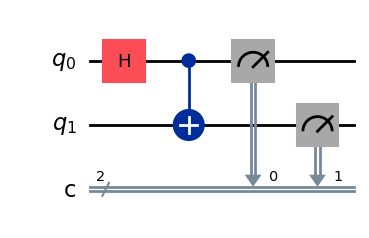

In [8]:
bell = QuantumCircuit(2, 2)

bell.h(0)          # Superposition on qubit 0
bell.cx(0, 1)      # CNOT: entangle qubit 0 and qubit 1
bell.measure([0, 1], [0, 1])

bell.draw('mpl')

Bell state counts: {'00': 510, '11': 514}


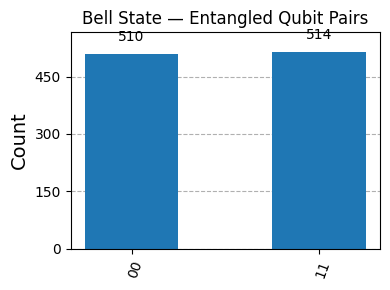

In [9]:
bell_t = transpile(bell, simulator)
bell_counts = simulator.run(bell_t, shots=1024).result().get_counts()
print("Bell state counts:", bell_counts)
plot_histogram(bell_counts, title='Bell State — Entangled Qubit Pairs', figsize=(4, 3))

### 4.2 — GHZ State (3-Qubit Entanglement)

The **Greenberger–Horne–Zeilinger (GHZ) state** extends entanglement to three qubits:

$$|GHZ\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$$

Only `000` and `111` outcomes are possible.

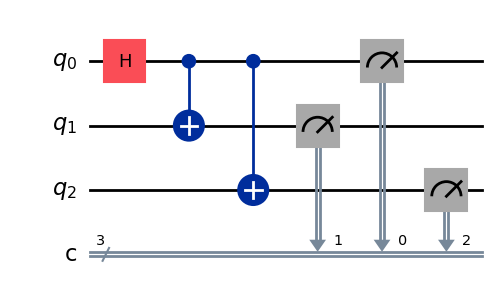

In [10]:
ghz = QuantumCircuit(3, 3)

ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)
ghz.measure([0, 1, 2], [0, 1, 2])

ghz.draw('mpl')

GHZ state counts: {'000': 497, '111': 527}


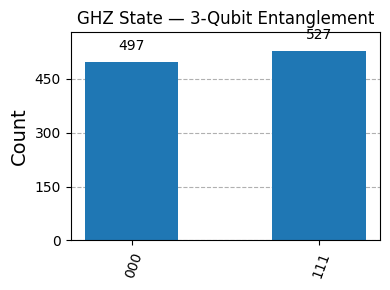

In [11]:
ghz_t = transpile(ghz, simulator)
ghz_counts = simulator.run(ghz_t, shots=1024).result().get_counts()
print("GHZ state counts:", ghz_counts)
plot_histogram(ghz_counts, title='GHZ State — 3-Qubit Entanglement', figsize=(4, 3))

---
## Section 5: Quantum Registers and the Toffoli Gate

For larger circuits, `QuantumRegister` and `ClassicalRegister` give named, grouped qubits — making circuits more readable and maintainable.

The **Toffoli gate** (CCX) is a 3-qubit gate: it flips the target qubit only if *both* control qubits are in state $|1\rangle$. It is the quantum equivalent of a classical AND gate and is universal for quantum computation.

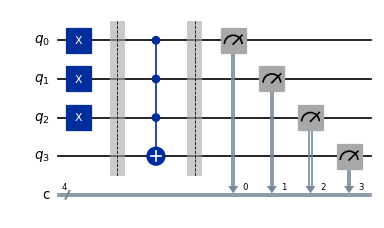

In [13]:
# Named registers — useful for larger, more structured circuits
qr = QuantumRegister(4, name='q')
cr = ClassicalRegister(4, name='c')
qc_reg = QuantumCircuit(qr, cr)

# Prepare control qubits in |1> using X gates
qc_reg.x(0)
qc_reg.x(1)
qc_reg.x(2)

# Barrier — visual separator, prevents optimiser from merging across it
qc_reg.barrier()

# Multi-control Toffoli: flip qubit 3 if qubits 0, 1, 2 are all |1>
qc_reg.mcx([0, 1, 2], 3)

qc_reg.barrier()
qc_reg.measure(qr, cr)

qc_reg.draw('mpl', scale=0.6)

Toffoli result (all controls |1> → target flips to |1>): {'1111': 512}


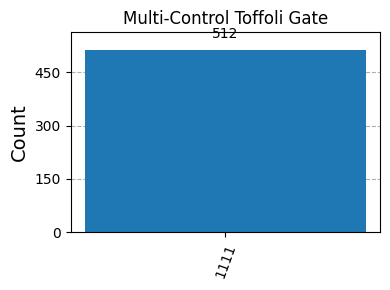

In [14]:
qc_reg_t = transpile(qc_reg, simulator)
reg_counts = simulator.run(qc_reg_t, shots=512).result().get_counts()
print("Toffoli result (all controls |1> → target flips to |1>):", reg_counts)
plot_histogram(reg_counts, title='Multi-Control Toffoli Gate', figsize=(4, 3))

**Expected:** all 512 shots measure `1111` — all three controls were $|1\rangle$, so the target qubit flipped.

---
## Section 6: State Visualisation — Density Matrix and Partial Trace

For entangled systems, we often want to examine one qubit in isolation. The **density matrix** $\rho = |\psi\rangle\langle\psi|$ is the general representation of a quantum state (pure or mixed). The **partial trace** traces out one subsystem, giving the reduced state of the other.

For the Bell state, tracing out one qubit gives a **maximally mixed state** — reflecting that each qubit individually is completely random, even though the pair is perfectly correlated.

In [15]:
# Build Bell state without measurement (we want the statevector)
bell_sv = QuantumCircuit(2)
bell_sv.h(0)
bell_sv.cx(0, 1)

# Compute full density matrix of the 2-qubit Bell state
rho_full = DensityMatrix(bell_sv)
print("Full 2-qubit density matrix:")
print(np.round(rho_full.data, 3))

Full 2-qubit density matrix:
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]


Reduced density matrix of qubit 0 (after tracing out qubit 1):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

This is the maximally mixed state I/2 — qubit 0 alone carries no information.


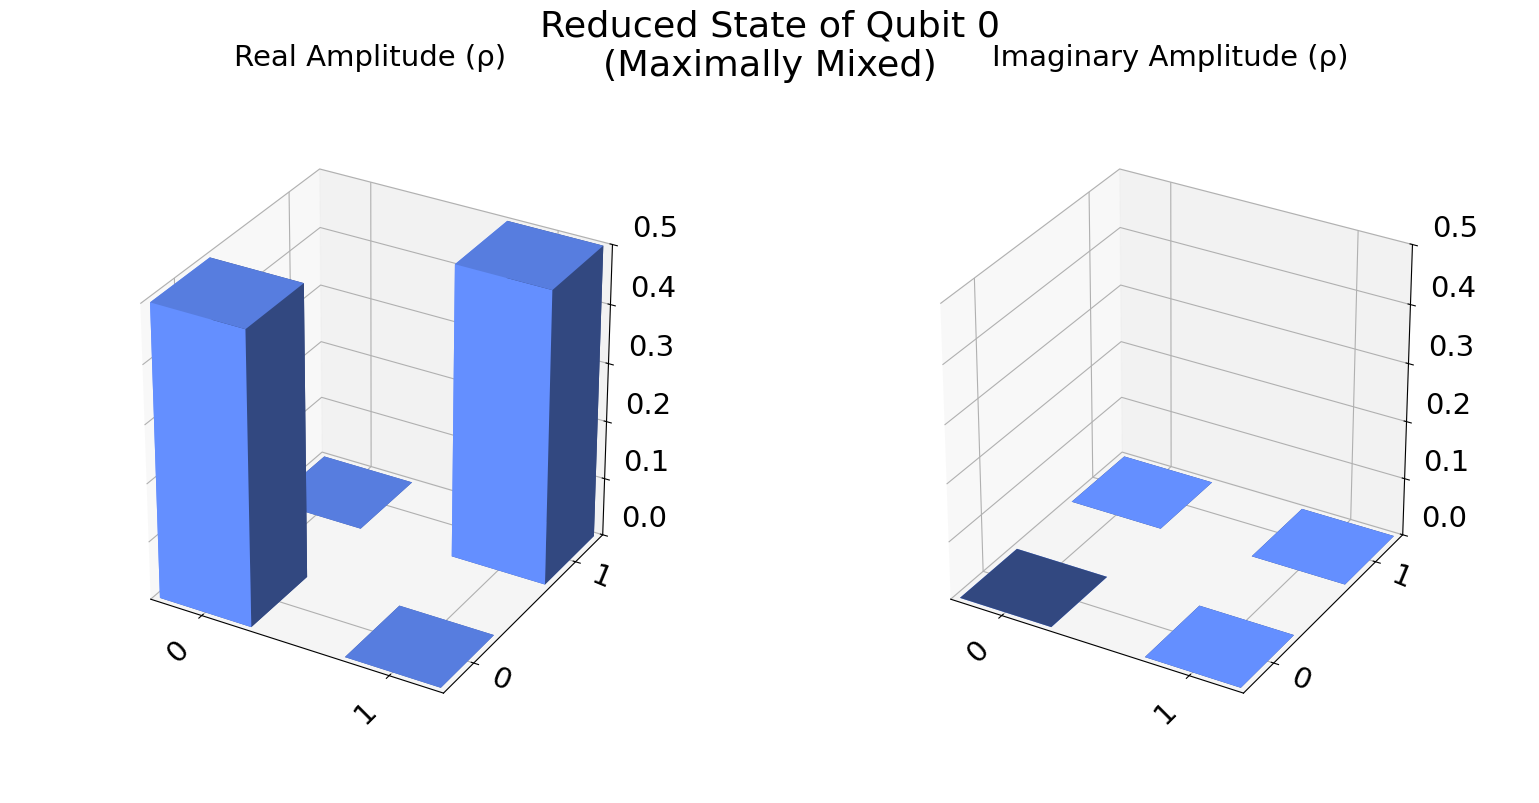

In [16]:
# Partial trace over qubit 1 — gives reduced state of qubit 0 alone
rho_0 = partial_trace(rho_full, [1])

print("Reduced density matrix of qubit 0 (after tracing out qubit 1):")
print(np.round(rho_0.data, 3))
print("\nThis is the maximally mixed state I/2 — qubit 0 alone carries no information.")

# Visualise as a 3D bar chart
plot_state_city(rho_0, title='Reduced State of Qubit 0\n(Maximally Mixed)')

---
## Section 7: Custom Gates, Controlled Gates, and Parametrised Circuits

### 7.1 — Custom Unitary Gate

Any unitary matrix can be directly inserted as a gate using `qc.unitary()`. Here we implement the Pauli-X gate manually as a $2 \times 2$ unitary.

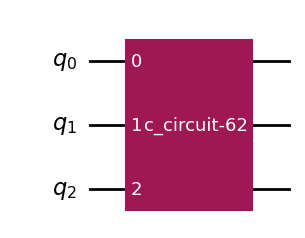

In [17]:
qc_custom = QuantumCircuit(2)

# Insert Pauli-X as a custom 2x2 unitary on qubit 0
qc_custom.unitary([[0, 1],
                   [1, 0]], 0, label='X (custom)')

# Convert to a controlled gate — control qubit added automatically
controlled = qc_custom.control(1)

qc_display = QuantumCircuit(3)
qc_display.append(controlled, [0, 1, 2])
qc_display.draw('mpl')

### 7.2 — Parametrised Circuits

**Parametrised circuits are the foundation of variational quantum algorithms** — including VQE, QAOA, and quantum machine learning. Instead of fixed gate angles, we use symbolic parameters that can be bound to concrete values at runtime.

This allows a classical optimiser to tune the circuit parameters to minimise an objective (e.g., ground state energy).

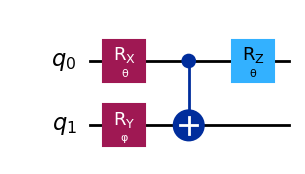

In [18]:
# Define symbolic parameters
theta = Parameter('θ')
phi   = Parameter('φ')

qc_param = QuantumCircuit(2)

# Rotation gates with symbolic angles
qc_param.rx(theta, 0)   # Rotation around X-axis by angle θ
qc_param.ry(phi, 1)     # Rotation around Y-axis by angle φ
qc_param.cx(0, 1)       # Entanglement
qc_param.rz(theta, 0)   # Re-use same parameter — allowed

qc_param.draw('mpl')

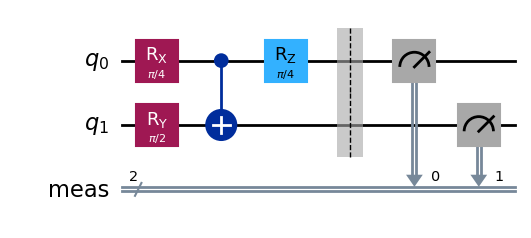

In [19]:
import numpy as np

# Bind concrete values to parameters at runtime
bound_circuit = qc_param.assign_parameters({theta: np.pi / 4,
                                             phi:   np.pi / 2})

bound_circuit.measure_all()
bound_circuit.draw('mpl')

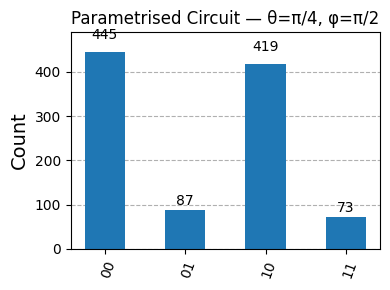

In [20]:
bound_t = transpile(bound_circuit, simulator)
bound_counts = simulator.run(bound_t, shots=1024).result().get_counts()
plot_histogram(bound_counts, title='Parametrised Circuit — θ=π/4, φ=π/2', figsize=(4, 3))

---
## Section 8: Transpilation — From Abstract to Hardware-Native

Real quantum hardware only supports a small set of native gates (e.g., `u`, `cx` on IBM devices). **Transpilation** rewrites your abstract circuit into this native gate set while preserving the operation.

This is essential for running on real hardware — and understanding it helps you write circuits that transpile efficiently.

In [21]:
# Build a circuit with high-level gates
# CCX (Toffoli) needs 3 distinct qubits: 2 controls + 1 target
qc_before = QuantumCircuit(3)
qc_before.h(0)
qc_before.cx(0, 1)
qc_before.ccx(0, 1, 2)  # controls=0,1  target=2

print("Before transpilation:")
print(f"  Gate count: {qc_before.size()}")
print(f"  Depth: {qc_before.depth()}")
print(f"  Operations: {dict(qc_before.count_ops())}")

Before transpilation:
  Gate count: 3
  Depth: 3
  Operations: {'h': 1, 'cx': 1, 'ccx': 1}


After transpilation to {u, cx} basis:
  Gate count: 16
  Depth: 12
  Operations: {'u': 9, 'cx': 7}


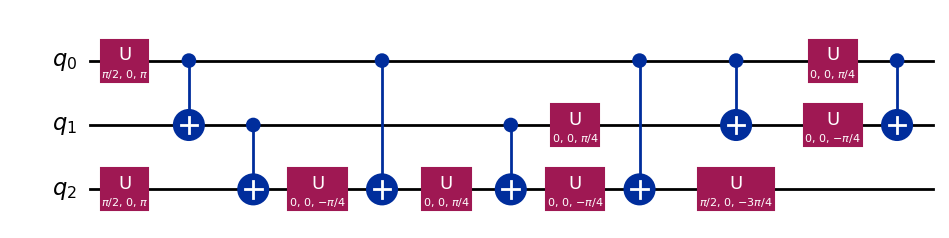

In [22]:
# Transpile to IBM-compatible basis gates {u, cx}
qc_after = transpile(qc_before, basis_gates=['u', 'cx'], optimization_level=3)

print("After transpilation to {u, cx} basis:")
print(f"  Gate count: {qc_after.size()}")
print(f"  Depth: {qc_after.depth()}")
print(f"  Operations: {dict(qc_after.count_ops())}")

qc_after.draw('mpl', fold=25)

---
## Section 9: Batching Multiple Circuits in a Single Job

Running circuits one-by-one is inefficient. Submitting a **batch** of circuits in a single job reduces overhead — critical when working with real hardware where queue time is expensive.

In [23]:
# Circuit 1: 2-qubit Bell state
qc_batch1 = QuantumCircuit(2)
qc_batch1.h(0)
qc_batch1.cx(0, 1)
qc_batch1.measure_all()

# Circuit 2: 3-qubit GHZ state
qc_batch2 = QuantumCircuit(3)
qc_batch2.h(0)
qc_batch2.cx(0, 1)
qc_batch2.cx(0, 2)
qc_batch2.measure_all()

# Circuit 3: Single-qubit Hadamard
qc_batch3 = QuantumCircuit(1)
qc_batch3.h(0)
qc_batch3.measure_all()

# Transpile the entire batch at once
batch = transpile([qc_batch1, qc_batch2, qc_batch3], simulator)

# Submit as a single job
job_batch = simulator.run(batch, shots=512)
results = job_batch.result()

print("Bell state counts: ",   results.get_counts(0))
print("GHZ state counts:  ",   results.get_counts(1))
print("Hadamard counts:   ",   results.get_counts(2))

Bell state counts:  {'00': 257, '11': 255}
GHZ state counts:   {'000': 267, '111': 245}
Hadamard counts:    {'1': 273, '0': 239}


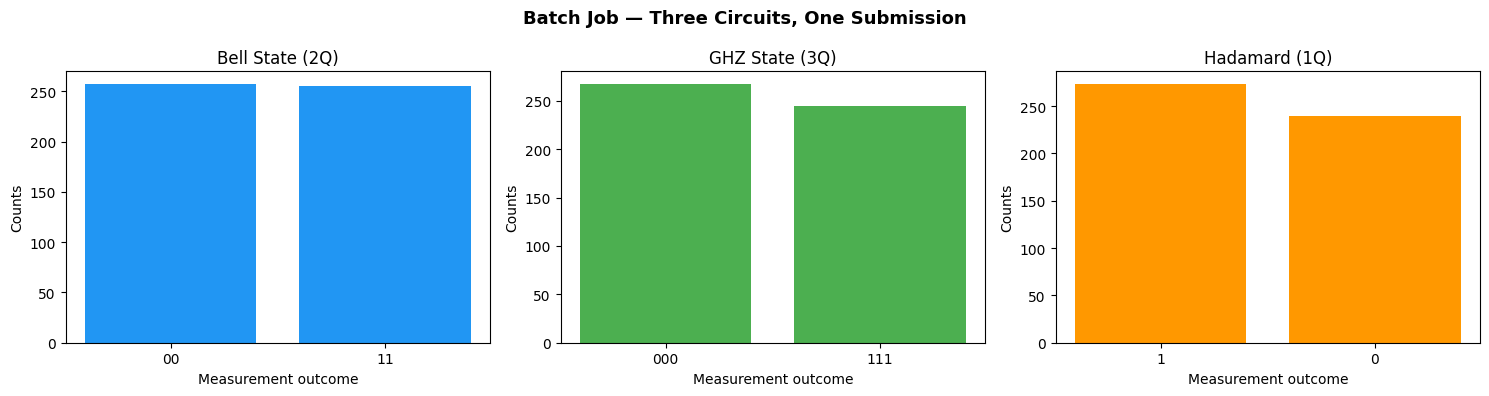

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ['Bell State (2Q)', 'GHZ State (3Q)', 'Hadamard (1Q)']
for i, (ax, title) in enumerate(zip(axes, titles)):
    counts = results.get_counts(i)
    ax.bar(counts.keys(), counts.values(), color=['#2196F3', '#4CAF50', '#FF9800'][i])
    ax.set_title(title)
    ax.set_xlabel('Measurement outcome')
    ax.set_ylabel('Counts')

plt.suptitle('Batch Job — Three Circuits, One Submission', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10: Quantum Volume

**Quantum Volume (QV)** is a single-number benchmark that captures the overall capability of a quantum processor — accounting for qubit count, connectivity, gate fidelity, and error rates simultaneously.

Introduced by IBM, QV = $2^n$ where $n$ is the largest number of qubits for which a square random circuit can be executed with sufficient fidelity. A higher QV means a more capable quantum computer.

The `QuantumVolume` class generates the benchmark circuits.

Quantum Volume circuit — 4 qubits
Depth (before decomposition): 1


/var/folders/yy/q9gk3w_957913dhpv652znlm0000gn/T/ipykernel_36339/1262953847.py:3: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qv_circuit = QuantumVolume(4, seed=42)  # seed for reproducibility


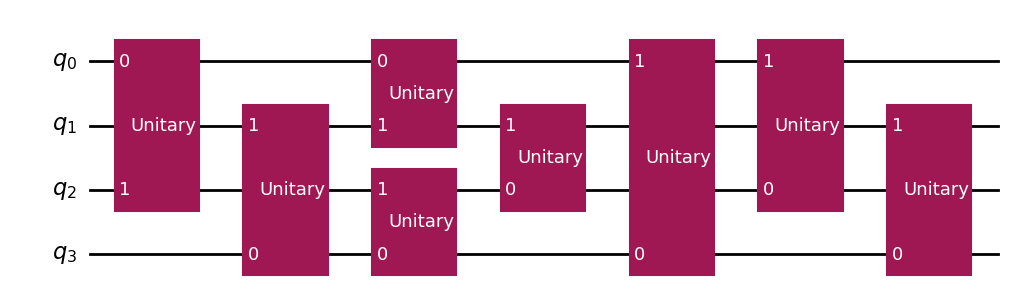

In [28]:
# Generate a 4-qubit Quantum Volume circuit
# Note: the circuit changes each run — it uses random SU(4) unitaries
qv_circuit = QuantumVolume(4, seed=42)  # seed for reproducibility

print(f"Quantum Volume circuit — {qv_circuit.num_qubits} qubits")
print(f"Depth (before decomposition): {qv_circuit.depth()}")

qv_circuit.decompose().draw('mpl', fold=40)

Top 10 Quantum Volume measurement outcomes:
  |1011⟩: 89
  |0000⟩: 70
  |0010⟩: 59
  |0011⟩: 38
  |0100⟩: 34
  |0101⟩: 32
  |1010⟩: 32
  |0110⟩: 29
  |0001⟩: 28
  |1110⟩: 25


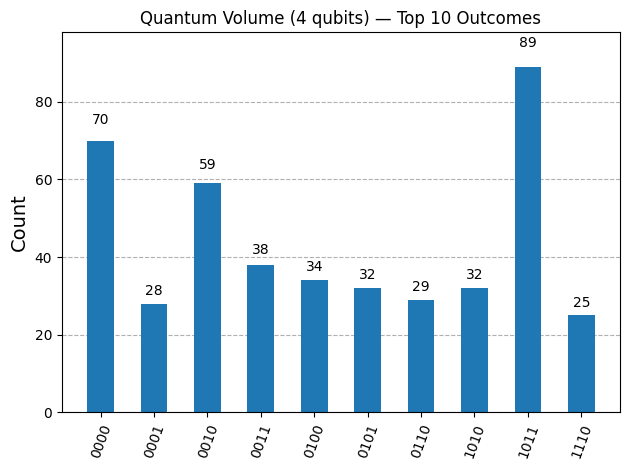

In [29]:
# Decompose and measure for simulation
qv_measure = qv_circuit.decompose()
qv_measure.measure_all()

qv_t = transpile(qv_measure, simulator, optimization_level=1)
qv_counts = simulator.run(qv_t, shots=512).result().get_counts()

# Show top 10 most frequent outcomes
sorted_counts = dict(sorted(qv_counts.items(), key=lambda x: x[1], reverse=True)[:10])
print("Top 10 Quantum Volume measurement outcomes:")
for state, count in sorted_counts.items():
    print(f"  |{state}⟩: {count}")

plot_histogram(sorted_counts,
               title='Quantum Volume (4 qubits) — Top 10 Outcomes')

---
## Summary

| Concept | What It Does | Why It Matters |
|---|---|---|
| `QuantumCircuit(n, m)` | Creates circuit with n qubits, m classical bits | Building block of all quantum programs |
| Hadamard gate `h()` | Creates superposition | Enables parallel computation |
| CNOT gate `cx()` | Creates entanglement | Powers quantum speedup |
| Toffoli gate `ccx()` / `mct()` | 3-qubit conditional flip | Universal quantum gate |
| `DensityMatrix` + `partial_trace` | Analyses subsystems of entangled states | Essential for quantum error correction |
| `Parameter` | Symbolic circuit angles | Foundation of VQE and variational algorithms |
| `transpile()` | Converts to hardware-native gates | Required for real device execution |
| Batch submission | Multiple circuits in one job | Efficient use of quantum hardware |
| `QuantumVolume` | Benchmark circuit | Measures overall processor capability |

---

## What Comes Next

The parametrised circuits in Section 7 are the direct building block of the **Variational Quantum Eigensolver (VQE)** — which uses a classical optimiser to tune those parameters and find the ground state energy of a Hamiltonian.

See the companion repository: [variational-quantum-eigensolver](https://github.com/fatahjamro/variational-quantum-eigensolver-vqe)

---

*Part of the [QuantumBeads](https://quantumbeads.com) open learning initiative.  
If this notebook was useful, consider starring the repository ⭐*